📂 Upload your grey_water_management.csv file...


Saving grey_water_management.csv to grey_water_management.csv

✅ Loaded → 19,656 rows × 7 columns
RUL range: 776h → 4617h (mean 2504h)

Normalization constants → turbidity_max: 9.9990 | flow_max: 99.9990 | tds_max: 499.9620

Train: 15,724 | Test: 3,932

⚙️  Training XGBoost...

[0]	validation_0-rmse:623.99545
[50]	validation_0-rmse:109.09252
[100]	validation_0-rmse:91.74498
[150]	validation_0-rmse:91.47684
[200]	validation_0-rmse:91.52236
[201]	validation_0-rmse:91.52605

  EVALUATION METRICS (Test Set)
  MAE   : 74.71 hours
  RMSE  : 91.45 hours
  R²    : 0.9805
  MAPE  : 3.08 %
  5-Fold CV R² : 0.9804 ± 0.0002


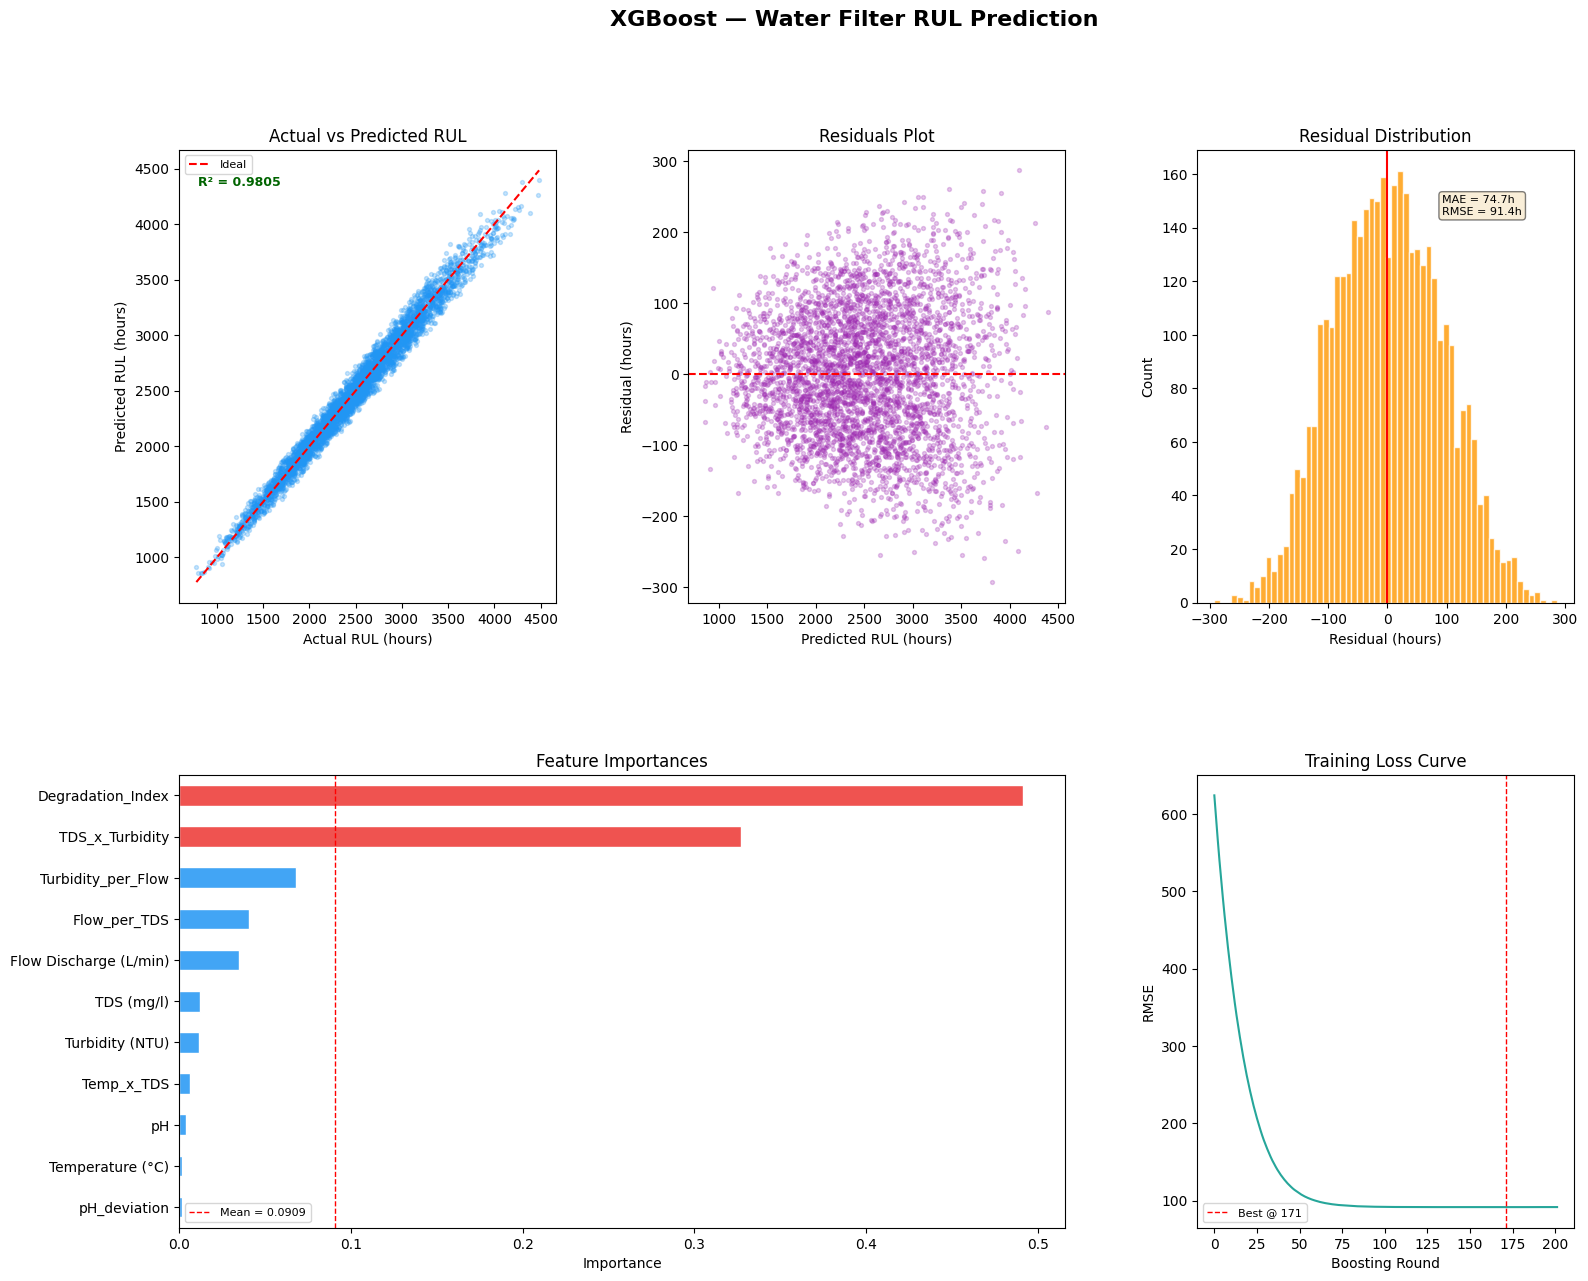


✅ CELL 1 COMPLETE — Run Cell 2 to save files


In [ ]:
# ============================================================
# XGBoost Water Filter RUL Estimator
# CELL 1 OF 2 — Train the model
# ============================================================

!pip install xgboost scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from google.colab import files
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)

# ----------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------
print("📂 Upload your grey_water_management.csv file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f"\n✅ Loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")

# ----------------------------------------------------------
# 2. Sensor columns & Temperature proxy
# ----------------------------------------------------------
SENSOR_COLS  = [
    "Flow Discharge (L/min)",
    "Turbidity (NTU)",
    "TDS (mg/l)",
    "pH",
]
LIFESPAN_COL = "Filter Life Span (hours)"

df["Temperature (°C)"] = (
    20
    + 0.015 * df["TDS (mg/l)"]
    - 0.3   * df["Turbidity (NTU)"]
    + np.random.normal(0, 0.5, len(df))
).clip(5, 40)
SENSOR_COLS.append("Temperature (°C)")

# ----------------------------------------------------------
# 3. Engineer RUL target
# ----------------------------------------------------------
stress_score = (
    df["TDS (mg/l)"]        / df["TDS (mg/l)"].max()              * 0.30
  + df["Turbidity (NTU)"]   / df["Turbidity (NTU)"].max()         * 0.30
  + (df["pH"] - 7).abs()    / 7                                    * 0.20
  + (1 - df["Flow Discharge (L/min)"] / df["Flow Discharge (L/min)"].max()) * 0.20
)
stress_score  = (stress_score + np.random.normal(0, 0.01, len(df))).clip(0, 0.99)
df["RUL (hours)"] = (df[LIFESPAN_COL] * (1 - stress_score)).round(2)

print(f"RUL range: {df['RUL (hours)'].min():.0f}h → {df['RUL (hours)'].max():.0f}h "
      f"(mean {df['RUL (hours)'].mean():.0f}h)")

# ----------------------------------------------------------
# 4. Feature Engineering
#    ⚠️ Save the normalization constants — needed in Flask later
# ----------------------------------------------------------
TURBIDITY_MAX = float(df["Turbidity (NTU)"].max())   # saved in Cell 2
FLOW_MAX      = float(df["Flow Discharge (L/min)"].max())
TDS_MAX       = float(df["TDS (mg/l)"].max())
print(f"\nNormalization constants → turbidity_max: {TURBIDITY_MAX:.4f} | "
      f"flow_max: {FLOW_MAX:.4f} | tds_max: {TDS_MAX:.4f}")

X = df[SENSOR_COLS].copy()
X["TDS_x_Turbidity"]   = X["TDS (mg/l)"]              * X["Turbidity (NTU)"]
X["pH_deviation"]       = (X["pH"] - 7).abs()
X["Flow_per_TDS"]       = X["Flow Discharge (L/min)"]  / (X["TDS (mg/l)"] + 1e-9)
X["Turbidity_per_Flow"] = X["Turbidity (NTU)"]         / (X["Flow Discharge (L/min)"] + 1e-9)
X["Temp_x_TDS"]         = X["Temperature (°C)"]        * X["TDS (mg/l)"]
X["Degradation_Index"]  = (
    X["TDS (mg/l)"]       / TDS_MAX
  + X["Turbidity (NTU)"] / TURBIDITY_MAX
  + X["pH_deviation"]    / 7
) / 3

y = df["RUL (hours)"]

# ----------------------------------------------------------
# 5. Train / Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

# ----------------------------------------------------------
# 6. Train Model
# ----------------------------------------------------------
model = XGBRegressor(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = "reg:squarederror",
    eval_metric           = "rmse",
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
)
print("\n⚙️  Training XGBoost...\n")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# ----------------------------------------------------------
# 7. Evaluate
# ----------------------------------------------------------
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

print("\n" + "="*45)
print("  EVALUATION METRICS (Test Set)")
print("="*45)
print(f"  MAE   : {mae:.2f} hours")
print(f"  RMSE  : {rmse:.2f} hours")
print(f"  R²    : {r2:.4f}")
print(f"  MAPE  : {mape:.2f} %")

cv_r2 = cross_val_score(
    XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="r2", n_jobs=-1
)
print(f"  5-Fold CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print("="*45)

# ----------------------------------------------------------
# 8. Plots
# ----------------------------------------------------------
fig = plt.figure(figsize=(18, 14))
fig.suptitle("XGBoost — Water Filter RUL Prediction",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.25, s=8, color="#2196F3")
mn, mx = y_test.min(), y_test.max()
ax1.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Ideal")
ax1.set_xlabel("Actual RUL (hours)"); ax1.set_ylabel("Predicted RUL (hours)")
ax1.set_title("Actual vs Predicted RUL"); ax1.legend(fontsize=8)
ax1.text(0.05, 0.92, f"R² = {r2:.4f}", transform=ax1.transAxes,
         fontsize=9, color="darkgreen", fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
residuals = y_test.values - y_pred
ax2.scatter(y_pred, residuals, alpha=0.25, s=8, color="#9C27B0")
ax2.axhline(0, color="red", lw=1.5, linestyle="--")
ax2.set_xlabel("Predicted RUL (hours)"); ax2.set_ylabel("Residual (hours)")
ax2.set_title("Residuals Plot")

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals, bins=60, color="#FF9800", edgecolor="white", alpha=0.8)
ax3.axvline(0, color="red", lw=1.5)
ax3.set_xlabel("Residual (hours)"); ax3.set_ylabel("Count")
ax3.set_title("Residual Distribution")
ax3.text(0.65, 0.9, f"MAE = {mae:.1f}h\nRMSE = {rmse:.1f}h",
         transform=ax3.transAxes, fontsize=8, va="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

ax4 = fig.add_subplot(gs[1, 0:2])
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors = ["#EF5350" if "Degradation" in n or "TDS_x" in n else "#42A5F5" for n in fi.index]
fi.plot(kind="barh", ax=ax4, color=colors, edgecolor="white")
ax4.set_title("Feature Importances"); ax4.set_xlabel("Importance")
ax4.axvline(fi.mean(), color="red", linestyle="--", lw=1,
            label=f"Mean = {fi.mean():.4f}")
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 2])
train_rmse = model.evals_result()["validation_0"]["rmse"]
ax5.plot(train_rmse, color="#26A69A", lw=1.5)
best = model.best_iteration
ax5.axvline(best, color="red", linestyle="--", lw=1, label=f"Best @ {best}")
ax5.set_xlabel("Boosting Round"); ax5.set_ylabel("RMSE")
ax5.set_title("Training Loss Curve"); ax5.legend(fontsize=8)

plt.tight_layout(); plt.show()
print("\n✅ CELL 1 COMPLETE — Run Cell 2 to save files")

In [ ]:
# ============================================================
# CELL 2 OF 2 — Save all files needed for Flask deployment
# ============================================================

import joblib
from google.colab import files

# Save model (native XGBoost .json format)
model.save_model('rul_xgboost.json')

# Save feature column names and order (CRITICAL)
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'rul_feature_columns.pkl')

# Save normalization constants used in Degradation_Index (CRITICAL)
# These are the .max() values from YOUR dataset — Flask must use the same numbers
normalization_constants = {
    'turbidity_max': TURBIDITY_MAX,
    'flow_max':      FLOW_MAX,
    'tds_max':       TDS_MAX,
}
joblib.dump(normalization_constants, 'rul_normalization_constants.pkl')

print("✅ Saved files:")
print(f"   rul_xgboost.json                   ← the trained model")
print(f"   rul_feature_columns.pkl            ← {feature_columns}")
print(f"   rul_normalization_constants.pkl    ← {normalization_constants}")
print("\n📥 Downloading all 3 files now...")

files.download('rul_xgboost.json')
files.download('rul_feature_columns.pkl')
files.download('rul_normalization_constants.pkl')

print("\n✅ Done! You should have 3 files downloaded.")

✅ Saved files:
   rul_xgboost.json                   ← the trained model
   rul_feature_columns.pkl            ← ['Flow Discharge (L/min)', 'Turbidity (NTU)', 'TDS (mg/l)', 'pH', 'Temperature (°C)', 'TDS_x_Turbidity', 'pH_deviation', 'Flow_per_TDS', 'Turbidity_per_Flow', 'Temp_x_TDS', 'Degradation_Index']
   rul_normalization_constants.pkl    ← {'turbidity_max': 9.999, 'flow_max': 99.999, 'tds_max': 499.962}

📥 Downloading all 3 files now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done! You should have 3 files downloaded.
